# Experiment 04 — Depth-4 Hybrid Topology Search: sin(x) and cos(x)

Extends experiment_03 in three ways:

1. **Deeper topology pool** — includes all Catalan shapes up to n=4 internal nodes
   (22 total: 1+2+5+14) via a Python port of the TypeScript `treesN` generator.
2. **Known phantoms skipped** — the 3 topologies that were phantom attractors in
   experiment_03 sin(x) search are excluded from the candidate pool.
3. **L1 regularisation** — `λ=1e-4` penalty on linear leaf weights pushes solutions
   toward simpler (sparser) constructions.

Targets: **sin(x)** and **cos(x)** on the 50-point grid `[0, 2π]`.
Leaf type: `FnLeaf` — `nn.Linear(1,1)` with near-zero weight init, bias=1.

In [1]:
import math, json, time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.facecolor": "#08090e", "axes.facecolor":   "#0d0f18",
    "axes.edgecolor":   "#1c1f2e", "axes.labelcolor":  "#d4d4d4",
    "text.color":       "#d4d4d4", "xtick.color":      "#4a4d62",
    "ytick.color":      "#4a4d62", "grid.color":       "#1c1f2e",
    "grid.linewidth":   0.5,       "lines.linewidth":  1.8,
    "font.family":      "monospace","font.size":        10,
})
ORANGE = "#e8a020"; BLUE = "#6ab0f5"; GREEN = "#4ade80"
RED    = "#f87171"; CYAN = "#67e8f9"; MUTED = "#4a4d62"

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"torch {torch.__version__}  |  device: {device}")

torch 2.11.0+cpu  |  device: cpu


In [2]:
# ── Differentiable EML building blocks (self-contained) ──────────────────────
# Matches monogate.network._LinearLeaf / _Node exactly.

class FnLeaf(nn.Module):
    """
    Linear leaf — nn.Linear(in_features, 1).
    Init: near-zero weights, bias=1 so every leaf starts ≈ 1 (EML-safe).
    forward(x): (batch, in_features) → (batch,)
    """
    def __init__(self, in_features: int = 1):
        super().__init__()
        self.linear = nn.Linear(in_features, 1, device=device)
        nn.init.uniform_(self.linear.weight, -0.05, 0.05)
        nn.init.ones_(self.linear.bias)

    def forward(self, x):
        return self.linear(x).squeeze(-1)   # (batch,)

    def formula(self, names=None):
        w      = self.linear.weight.data.squeeze(0)
        b      = self.linear.bias.data.item()
        labels = names or [f"x{i}" for i in range(w.shape[0])]
        parts  = [f"{w[i].item():.4g}*{labels[i]}" for i in range(w.shape[0])
                  if abs(w[i].item()) > 1e-4]
        if abs(b) > 1e-4:
            parts.append(f"{b:.4g}")
        return "(" + ("+".join(parts) if parts else "0") + ")"


class EMLNode(nn.Module):
    """eml(left, right) = exp(left) − ln(right). softplus keeps rv > 0."""
    def __init__(self, left: nn.Module, right: nn.Module):
        super().__init__()
        self.left, self.right = left, right

    def forward(self, x=None):
        lv = self.left(x)
        rv = F.softplus(self.right(x))
        return torch.exp(lv) - torch.log(rv)

    def formula(self, names=None):
        return f"eml({self.left.formula(names)}, {self.right.formula(names)})"


def build(shape, leaf_fn):
    """Recursively build a fresh EML tree from a shape spec + leaf factory."""
    if shape == 'L':
        return leaf_fn()
    return EMLNode(build(shape[1], leaf_fn), build(shape[2], leaf_fn))


def _leaves(s):  return 1 if s == 'L' else _leaves(s[1]) + _leaves(s[2])
def _depth(s):   return 0 if s == 'L' else 1 + max(_depth(s[1]), _depth(s[2]))
def _desc(s):    return '1' if s == 'L' else f"eml({_desc(s[1])},{_desc(s[2])})"

print("Building blocks defined.")

Building blocks defined.


In [3]:
# ── treesN: Python port of challenge/lib/complex-search.ts:treesN() ──────────
#
# Memoised Catalan enumeration — all full-binary trees with exactly n internal
# nodes. Catalan counts: n=0→1, 1→1, 2→2, 3→5, 4→14  (cumulative 1..4: 22)

_tc_memo: dict = {}

def trees_n(n: int) -> list:
    """All shape tuples with exactly n EML nodes (same semantics as treesN in TS)."""
    if n in _tc_memo:
        return _tc_memo[n]
    if n == 0:
        _tc_memo[0] = ['L']
        return _tc_memo[0]
    result = []
    for i in range(n):
        for l in trees_n(i):
            for r in trees_n(n - 1 - i):
                result.append(('N', l, r))
    _tc_memo[n] = result
    return result


# ── Build candidate pool: n=1..4, skip 3 known phantoms ──────────────────────
#
# Phantoms identified in experiment_03 sin(x) results:
#   eml(1,1)              depth-1: only 2 leaves, too weak for function approx
#   eml(eml(1,1),1)       depth-2a: all restarts trap in same bad basin
#   eml(eml(1,eml(1,1)),1) depth-3b: phantom confirmed across 5 restarts
PHANTOM_DESCS = {
    'eml(1,1)',
    'eml(eml(1,1),1)',
    'eml(eml(1,eml(1,1)),1)',
}

SHAPES_04 = [
    s for n in range(1, 5)
    for s in trees_n(n)
    if _desc(s) not in PHANTOM_DESCS
]

print(f"Catalan counts  n=1..4: {[len(trees_n(n)) for n in range(1,5)]}  → total 22")
print(f"After skipping {len(PHANTOM_DESCS)} phantoms: {len(SHAPES_04)} candidate topologies\n")
print(f"{'ID':<4} {'D':<4} {'L':<5} Topology")
print("─" * 62)
for i, s in enumerate(SHAPES_04):
    print(f"{i:<4} {_depth(s):<4} {_leaves(s):<5} {_desc(s)}")

Catalan counts  n=1..4: [1, 2, 5, 14]  → total 22
After skipping 3 phantoms: 19 candidate topologies

ID   D    L     Topology
──────────────────────────────────────────────────────────────
0    2    3     eml(1,eml(1,1))
1    3    4     eml(1,eml(1,eml(1,1)))
2    3    4     eml(1,eml(eml(1,1),1))
3    2    4     eml(eml(1,1),eml(1,1))
4    3    4     eml(eml(eml(1,1),1),1)
5    4    5     eml(1,eml(1,eml(1,eml(1,1))))
6    4    5     eml(1,eml(1,eml(eml(1,1),1)))
7    3    5     eml(1,eml(eml(1,1),eml(1,1)))
8    4    5     eml(1,eml(eml(1,eml(1,1)),1))
9    4    5     eml(1,eml(eml(eml(1,1),1),1))
10   3    5     eml(eml(1,1),eml(1,eml(1,1)))
11   3    5     eml(eml(1,1),eml(eml(1,1),1))
12   3    5     eml(eml(1,eml(1,1)),eml(1,1))
13   3    5     eml(eml(eml(1,1),1),eml(1,1))
14   4    5     eml(eml(1,eml(1,eml(1,1))),1)
15   4    5     eml(eml(1,eml(eml(1,1),1)),1)
16   3    5     eml(eml(eml(1,1),eml(1,1)),1)
17   4    5     eml(eml(eml(1,eml(1,1)),1),1)
18   4    5     eml(eml(

In [4]:
# ── search_fn: topology × restart × step loop with L1 regularisation ─────────
#
# lam=1e-4 L1 penalty on linear leaf weights → pushes toward sparse/constant
# leaves, mild enough not to dominate MSE but enough to break symmetry.
# Raw MSE (without penalty) is tracked for fair ranking.

def search_fn(
    shapes, x_in, y_target, target_name,
    lam: float = 1e-4,
    num_restarts: int = 5,
    steps: int = 1000,
    lr: float = 0.01,
):
    """
    Returns: (records_sorted_by_loss, global_best_model)
    records keys: shape, depth, leaves, nodes, desc, loss, phantom, formula, _model
    """
    records = []
    global_best_loss, global_best_model = float('inf'), None

    for shape in shapes:
        r_losses = []
        best_loss, best_model = float('inf'), None

        for r in range(num_restarts):
            torch.manual_seed(r * 1000 + 13)
            model = build(shape, lambda: FnLeaf(in_features=1))
            opt   = torch.optim.Adam(model.parameters(), lr=lr)
            last  = float('inf')

            for _ in range(steps):
                opt.zero_grad()
                try:
                    pred     = model(x_in)                 # (50,)
                    raw_loss = F.mse_loss(pred, y_target)  # MSE over all 50 pts
                    if not torch.isfinite(raw_loss): break
                    # L1 on weight tensors only (not bias) — mild complexity penalty
                    l1_pen = lam * sum(
                        p.abs().sum()
                        for nm, p in model.named_parameters()
                        if 'weight' in nm
                    )
                    (raw_loss + l1_pen).backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
                    last = raw_loss.item()   # track raw MSE for ranking
                except Exception:
                    break

            r_losses.append(last)
            if last < best_loss:
                best_loss, best_model = last, model

        # Phantom: spread across restarts is tiny AND best loss is still poor
        spread = max(r_losses) - min(r_losses)
        is_ph  = (min(r_losses) > 1e-3) and (spread < 1e-3)

        records.append(dict(
            shape=shape, depth=_depth(shape), leaves=_leaves(shape),
            nodes=_leaves(shape) - 1, desc=_desc(shape),
            loss=best_loss, phantom=is_ph,
            formula=best_model.formula(['x']) if best_model else 'N/A',
            _model=best_model,
        ))

        if best_loss < global_best_loss:
            global_best_loss, global_best_model = best_loss, best_model

    records.sort(key=lambda r: r['loss'])
    return records, global_best_model


print("search_fn defined (lam=1e-4 L1, 5 restarts, 1000 steps).")

search_fn defined (lam=1e-4 L1, 5 restarts, 1000 steps).


In [5]:
# ── Data ──────────────────────────────────────────────────────────────────────
x_grid     = torch.linspace(0, 2 * math.pi, 50, device=device)  # (50,)
sin_target = torch.sin(x_grid)                                    # (50,)
cos_target = torch.cos(x_grid)                                    # (50,)
x_in       = x_grid.unsqueeze(1)                                  # (50, 1)

# ── sin(x) search ─────────────────────────────────────────────────────────────
N_TOT = len(SHAPES_04)
print(f"sin(x) — {N_TOT} topologies × 5 restarts × 1000 steps ...")
t0 = time.perf_counter()
sin_results, best_sin_model = search_fn(SHAPES_04, x_in, sin_target, 'sin(x)')
print(f"Done in {time.perf_counter()-t0:.1f}s\n")

print(f"{'#':<4} {'D':<4} {'L':<4} {'MSE':<14} {'PH':<5} Formula")
print("─" * 85)
for i, r in enumerate(sin_results[:10]):
    ph = 'Y' if r['phantom'] else ''
    print(f"{i+1:<4} {r['depth']:<4} {r['leaves']:<4} {r['loss']:<14.4e} {ph:<5} {r['formula'][:50]}")

sin(x) — 19 topologies × 5 restarts × 1000 steps ...


Done in 308.5s

#    D    L    MSE            PH    Formula
─────────────────────────────────────────────────────────────────────────────────────
1    4    5    7.7607e-04           eml((0.3487*x+-0.1946), eml(eml((0.1521*x+0.693), 
2    3    5    2.1369e-03     Y     eml(eml((0.2189*x+-0.1856), (0.6403*x+2.289)), eml
3    3    5    2.4341e-03     Y     eml((0.3905*x+-0.4056), eml(eml((0.1353*x+-0.1497)
4    4    5    2.4891e-03     Y     eml((0.4785*x+-1.483), eml((0.8484*x+-0.6432), eml
5    2    3    2.7725e-03     Y     eml((0.4726*x+-1.327), eml((1.118*x+-1.826), (2.30
6    3    4    2.8601e-03     Y     eml((0.4722*x+-1.508), eml((0.7229*x+-0.05369), em
7    2    4    3.0001e-03           eml(eml((0.2137*x+-0.128), (0.6294*x+2.137)), eml(
8    3    5    4.1727e-03           eml(eml((-0.2397*x+0.7645), eml((0.5544*x+-1.012),
9    3    5    9.2577e-03           eml(eml(eml((0.1982*x+-0.1171), (0.7561*x+2.179)),
10   4    5    9.3377e-03           eml(eml(eml((-0.142*x+0.4069), eml(

In [6]:
# ── cos(x) search ─────────────────────────────────────────────────────────────
print(f"cos(x) — {N_TOT} topologies × 5 restarts × 1000 steps ...")
t0 = time.perf_counter()
cos_results, best_cos_model = search_fn(SHAPES_04, x_in, cos_target, 'cos(x)')
print(f"Done in {time.perf_counter()-t0:.1f}s\n")

print(f"{'#':<4} {'D':<4} {'L':<4} {'MSE':<14} {'PH':<5} Formula")
print("─" * 85)
for i, r in enumerate(cos_results[:10]):
    ph = 'Y' if r['phantom'] else ''
    print(f"{i+1:<4} {r['depth']:<4} {r['leaves']:<4} {r['loss']:<14.4e} {ph:<5} {r['formula'][:50]}")

cos(x) — 19 topologies × 5 restarts × 1000 steps ...


Done in 282.9s

#    D    L    MSE            PH    Formula
─────────────────────────────────────────────────────────────────────────────────────
1    4    5    1.6162e-03           eml((-0.7915*x+0.5674), eml((-0.5434*x+1.758), eml
2    4    5    2.0701e-03           eml((-0.3059*x+0.5945), eml(eml((0.1263*x+0.4228),
3    3    5    3.4834e-03     Y     eml(eml((-0.2134*x+0.841), eml((0.5504*x+0.01264),
4    3    5    1.5663e-02           eml(eml(eml((-0.08612*x+0.4115), (0.2777*x+1.599))
5    4    5    1.6670e-02     Y     eml(eml((-0.477*x+0.5563), eml((0.7623*x+0.3416), 
6    4    5    1.6819e-02     Y     eml(eml(eml((-0.1198*x+0.5214), eml((0.3745*x+0.38
7    4    5    2.7703e-02           eml((-0.7026*x+0.6217), eml((-0.5601*x+2.639), eml
8    3    4    2.9297e-02           eml((-0.5974*x+1.205), eml((-0.4165*x+2.409), eml(
9    3    5    4.5711e-02           eml((0.3061*x+0.354), eml(eml((-0.005118*x+0.3707)
10   2    3    5.0084e-02     Y     eml((-0.4159*x+1.747), eml((-0.5412

C:\Users\almag\AppData\Roaming\Python\Python314\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
C:\Users\almag\AppData\Roaming\Python\Python314\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


C:\Users\almag\AppData\Roaming\Python\Python314\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


Saved → D:\monogate\python\notebooks\experiment_04_results.png


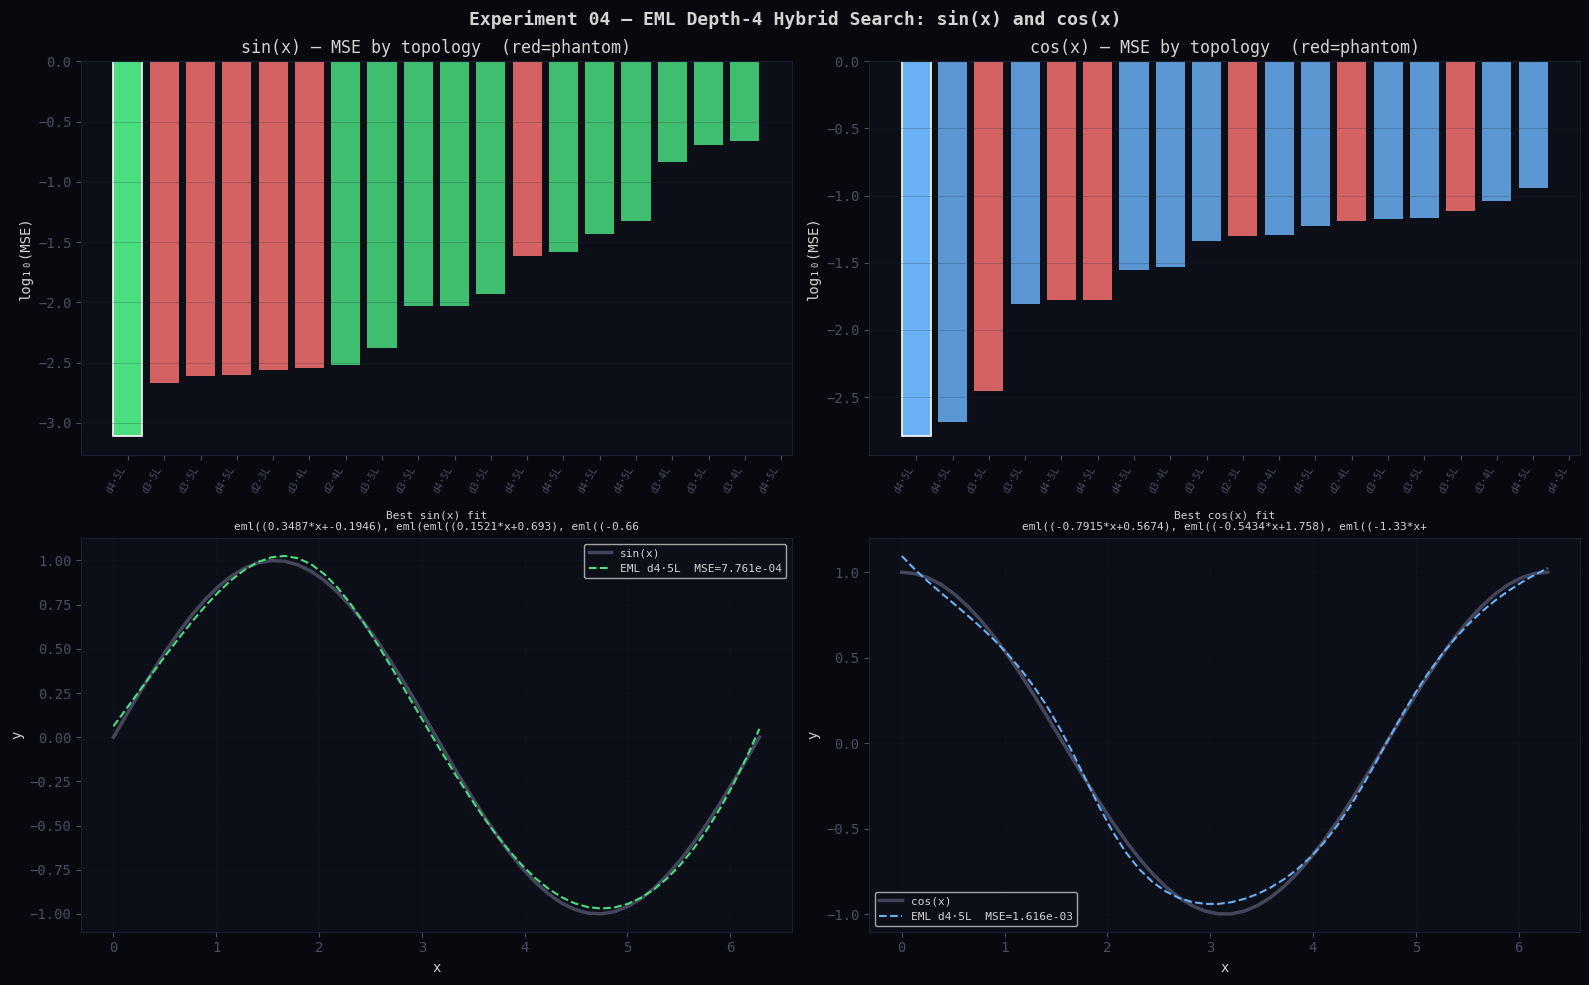

In [7]:
# ── 4-panel figure ────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Experiment 04 — EML Depth-4 Hybrid Search: sin(x) and cos(x)',
             color='#d4d4d4', fontsize=13, fontweight='bold')

# ── Panel A: sin(x) MSE ranking ───────────────────────────────────────────────
ax      = axes[0, 0]
labels  = [f"d{r['depth']}·{r['leaves']}L" for r in sin_results]
log_mse = np.log10(np.array([r['loss'] for r in sin_results]) + 1e-20)
colors  = [RED if r['phantom'] else GREEN for r in sin_results]
ax.bar(range(len(labels)), log_mse, color=colors, alpha=0.85)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=60, ha='right', fontsize=7)
ax.set_ylabel('log₁₀(MSE)')
ax.set_title('sin(x) — MSE by topology  (red=phantom)', color='#d4d4d4')
ax.grid(True, axis='y', alpha=0.3)
# annotate best
ax.bar(0, log_mse[0], color=GREEN, edgecolor='white', linewidth=1.2, alpha=1.0)

# ── Panel B: cos(x) MSE ranking ───────────────────────────────────────────────
ax      = axes[0, 1]
labels2 = [f"d{r['depth']}·{r['leaves']}L" for r in cos_results]
log_mse2 = np.log10(np.array([r['loss'] for r in cos_results]) + 1e-20)
colors2  = [RED if r['phantom'] else BLUE for r in cos_results]
ax.bar(range(len(labels2)), log_mse2, color=colors2, alpha=0.85)
ax.set_xticks(range(len(labels2)))
ax.set_xticklabels(labels2, rotation=60, ha='right', fontsize=7)
ax.set_ylabel('log₁₀(MSE)')
ax.set_title('cos(x) — MSE by topology  (red=phantom)', color='#d4d4d4')
ax.grid(True, axis='y', alpha=0.3)
ax.bar(0, log_mse2[0], color=BLUE, edgecolor='white', linewidth=1.2, alpha=1.0)

# ── Panel C: best sin(x) fit ──────────────────────────────────────────────────
ax     = axes[1, 0]
x_np   = x_grid.cpu().numpy()
y_sin  = sin_target.cpu().numpy()
with torch.no_grad():
    y_sin_pred = best_sin_model(x_in).cpu().numpy()
bs = sin_results[0]
ax.plot(x_np, y_sin,      color=MUTED, linewidth=2.5, label='sin(x)', alpha=0.9)
ax.plot(x_np, y_sin_pred, color=GREEN, linewidth=1.5, linestyle='--',
        label=f"EML d{bs['depth']}·{bs['leaves']}L  MSE={bs['loss']:.3e}")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f"Best sin(x) fit\n{bs['formula'][:60]}", color='#d4d4d4', fontsize=8)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# ── Panel D: best cos(x) fit ──────────────────────────────────────────────────
ax     = axes[1, 1]
y_cos  = cos_target.cpu().numpy()
with torch.no_grad():
    y_cos_pred = best_cos_model(x_in).cpu().numpy()
bc = cos_results[0]
ax.plot(x_np, y_cos,      color=MUTED, linewidth=2.5, label='cos(x)', alpha=0.9)
ax.plot(x_np, y_cos_pred, color=BLUE,  linewidth=1.5, linestyle='--',
        label=f"EML d{bc['depth']}·{bc['leaves']}L  MSE={bc['loss']:.3e}")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f"Best cos(x) fit\n{bc['formula'][:60]}", color='#d4d4d4', fontsize=8)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

plt.tight_layout()
out_dir  = Path('D:/monogate/python/notebooks')
out_path = out_dir / 'experiment_04_results.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f"Saved → {out_path}")
plt.show()

In [8]:
# ── JSON export + summary ─────────────────────────────────────────────────────

def _ser(r):
    return {k: (str(v) if k == 'shape' else v)
            for k, v in r.items() if k != '_model'}

out_dir   = Path('D:/monogate/python/notebooks')
json_path = out_dir / 'experiment_04_results.json'
json_path.write_text(json.dumps({
    'sin': [_ser(r) for r in sin_results],
    'cos': [_ser(r) for r in cos_results],
}, indent=2), encoding='utf-8')
print(f"Saved → {json_path}")

bs = sin_results[0]
bc = cos_results[0]
n_ph_sin = sum(1 for r in sin_results if r['phantom'])
n_ph_cos = sum(1 for r in cos_results if r['phantom'])

print("\n" + "═" * 66)
print("EXPERIMENT 04 — RESULTS SUMMARY")
print("═" * 66)
print(f"  Topology pool : {len(SHAPES_04)} shapes (n=1..4, 3 known phantoms excluded)")
print(f"  Restarts      : 5   |   Steps: 1000   |   λ_L1: 1e-4")

print(f"\n  Best sin(x) topology:")
print(f"    Depth   : {bs['depth']}")
print(f"    Nodes   : {bs['nodes']}")
print(f"    Leaves  : {bs['leaves']}")
print(f"    MSE     : {bs['loss']:.4e}")
print(f"    Formula : {bs['formula']}")
print(f"    Phantom : {bs['phantom']}")

print(f"\n  Best cos(x) topology:")
print(f"    Depth   : {bc['depth']}")
print(f"    Nodes   : {bc['nodes']}")
print(f"    Leaves  : {bc['leaves']}")
print(f"    MSE     : {bc['loss']:.4e}")
print(f"    Formula : {bc['formula']}")
print(f"    Phantom : {bc['phantom']}")

print(f"\n  Phantom attractors:")
print(f"    sin(x): {n_ph_sin} / {len(sin_results)}")
print(f"    cos(x): {n_ph_cos} / {len(cos_results)}")

# Highlight any topology that is best for BOTH targets
if bs['desc'] == bc['desc']:
    print(f"\n  *** Same topology wins both targets: {bs['desc']} ***")

print("\n  experiment_04 complete!")

Saved → D:\monogate\python\notebooks\experiment_04_results.json

══════════════════════════════════════════════════════════════════
EXPERIMENT 04 — RESULTS SUMMARY
══════════════════════════════════════════════════════════════════
  Topology pool : 19 shapes (n=1..4, 3 known phantoms excluded)
  Restarts      : 5   |   Steps: 1000   |   λ_L1: 1e-4

  Best sin(x) topology:
    Depth   : 4
    Nodes   : 4
    Leaves  : 5
    MSE     : 7.7607e-04
    Formula : eml((0.3487*x+-0.1946), eml(eml((0.1521*x+0.693), eml((-0.6698*x+3.381), (1.788*x+0.8609))), (1.594*x+-1.677)))
    Phantom : False

  Best cos(x) topology:
    Depth   : 4
    Nodes   : 4
    Leaves  : 5
    MSE     : 1.6162e-03
    Formula : eml((-0.7915*x+0.5674), eml((-0.5434*x+1.758), eml((-1.33*x+4.109), eml((-1.07*x+6.227), (3.736*x+2.355)))))
    Phantom : False

  Phantom attractors:
    sin(x): 6 / 19
    cos(x): 6 / 19

  experiment_04 complete!
